<a href="https://colab.research.google.com/github/rawanii11/-task2-qa-demo/blob/main/AI_ASS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rawanalharmali","key":"ddf27f017b3ccbab0cf091acb75b4ff2"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d phylake1337/fire-dataset

Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset
License(s): CC0-1.0
100% 387M/387M [00:02<00:00, 140MB/s]



In [ ]:
!unzip fire-dataset.zip

Archive:  fire-dataset.zip
  inflating: fire_dataset/fire_images/fire.1.png  
  inflating: fire_dataset/fire_images/fire.10.png  
  inflating: fire_dataset/fire_images/fire.100.png  
  inflating: fire_dataset/fire_images/fire.101.png  
  inflating: fire_dataset/fire_images/fire.102.png  
  inflating: fire_dataset/fire_images/fire.103.png  
  inflating: fire_dataset/fire_images/fire.104.png  
  inflating: fire_dataset/fire_images/fire.105.png  
  inflating: fire_dataset/fire_images/fire.106.png  
  inflating: fire_dataset/fire_images/fire.107.png  
  inflating: fire_dataset/fire_images/fire.108.png  
  inflating: fire_dataset/fire_images/fire.109.png  
  inflating: fire_dataset/fire_images/fire.11.png  
  inflating: fire_dataset/fire_images/fire.110.png  
  inflating: fire_dataset/fire_images/fire.111.png  
  inflating: fire_dataset/fire_images/fire.112.png  
  inflating: fire_dataset/fire_images/fire.113.png  
  inflating: fire_dataset/fire_images/fire.114.png  
  inflating: fire_datas

In [ ]:
!ls

'archive (2).zip'   fire-dataset.zip   kaggle.json
 fire_dataset	   'kaggle (1).json'   sample_data


In [ ]:
!ls fire_dataset

fire_images  non_fire_images


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
!ls

'archive (2).zip'   fire-dataset.zip   kaggle.json
 fire_dataset	   'kaggle (1).json'   sample_data


In [ ]:
!unzip dataset.zip -d /content/

unzip:  cannot find or open dataset.zip, dataset.zip.zip or dataset.zip.ZIP.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# 1. DATA PREPARATION (Requirement 1c-v)
# Using Data Augmentation to prevent overfitting (Requirement 1c-vii)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

# Load data from the 'fire_dataset' folder seen in your screenshot
train_gen = train_datagen.flow_from_directory(
    '/content/fire_dataset',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    '/content/fire_dataset',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# 2. CUSTOM CNN MODEL (Requirement 1c-vi)
custom_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Solution for overfitting
    layers.Dense(1, activation='sigmoid')
])

custom_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. PRE-TRAINED MODEL (MobileNetV2) (Requirement 1c-vi)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze layers

pretrained_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

pretrained_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. TRAINING
print("Starting training for Custom Model...")
history_custom = custom_model.fit(train_gen, validation_data=val_gen, epochs=10)

print("\nStarting training for Pre-trained Model...")
history_pre = pretrained_model.fit(train_gen, validation_data=val_gen, epochs=5)

Found 800 images belonging to 2 classes.
Found 199 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training for Custom Model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.7875 - loss: 0.6363 - val_accuracy: 0.8945 - val_loss: 0.2298
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 102s 4s/step - accuracy: 0.9513 - loss: 0.1707 - val_accuracy: 0.9045 - val_loss: 0.2510
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.9350 - loss: 0.1598 - val_accuracy: 0.9397 - val_loss: 0.1859
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 102s 4s/step - accuracy: 0.9538 - loss: 0.1214 - val_accuracy: 0.9246 - val_loss: 0.2309
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.9575 - loss: 0.1246 - val_accuracy: 0.9296 - val_loss: 0.1443
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.9625 - loss: 0.1056 - val_accuracy: 0.9246 - val_loss: 0.1847
Epoch 7/10
 5/25 ━━━━━━━━━━━━━━━━━━━━ 1:09 3s/step - accuracy: 0.9910 - loss: 0.0490

In [ ]:
# Install kaggle library
!pip install -q kaggle

# Upload your kaggle.json file
from google.colab import files
files.upload()

# Set up Kaggle directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d phylake1337/fire-dataset
!unzip -q fire-dataset.zip -d /content/

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset
License(s): CC0-1.0
100% 387M/387M [00:05<00:00, 74.8MB/s]



In [6]:
import os

dataset_path = '/content/fire_dataset'

# Check if the dataset directory exists
if not os.path.exists(dataset_path):
    print(f"Directory '{dataset_path}' not found. Re-downloading and unzipping dataset...")
    # Ensure kaggle.json is already set up in ~/.kaggle/ for this to work
    !kaggle datasets download -d phylake1337/fire-dataset
    !unzip -o fire-dataset.zip -d /content/
    print("Dataset re-downloaded and unzipped.")
else:
    print(f"Directory '{dataset_path}' already exists. Proceeding...")

Directory '/content/fire_dataset' not found. Re-downloading and unzipping dataset...
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset
License(s): CC0-1.0
100% 387M/387M [00:02<00:00, 172MB/s]

Archive:  fire-dataset.zip
  inflating: /content/fire_dataset/fire_images/fire.1.png  
  inflating: /content/fire_dataset/fire_images/fire.10.png  
  inflating: /content/fire_dataset/fire_images/fire.100.png  
  inflating: /content/fire_dataset/fire_images/fire.101.png  
  inflating: /content/fire_dataset/fire_images/fire.102.png  
  inflating: /content/fire_dataset/fire_images/fire.103.png  
  inflating: /content/fire_dataset/fire_images/fire.104.png  
  inflating: /content/fire_dataset/fire_images/fire.105.png  
  inflating: /content/fire_dataset/fire_images/fire.106.png  
  inflating: /content/fire_dataset/fire_images/fire.107.png  
  inflating: /content/fire_dataset/fire_images/fire.108.png  
  inflating: /content/fire_dataset/fire_images/fire.109.png  
  inflating: /cont

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# The path must match the folder created after unzipping your file.
# Based on your screenshot, the correct path is '/content/fire_dataset'

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

train_generator = datagen.flow_from_directory(
    '/content/fire_dataset', # Updated path to match your folder structure
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    '/content/fire_dataset', # Updated path to match your folder structure
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 800 images belonging to 2 classes.
Found 199 images belonging to 2 classes.


In [9]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# --- STEP 1: DEFINE AND TRAIN CUSTOM CNN ---
# This satisfies the "proposed convolutional neural network model" requirement [cite: 57]
custom_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Solution for overfitting [cite: 63]
    layers.Dense(1, activation='sigmoid')
])

custom_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Custom CNN Model...")
# Use the generators you just created
history_custom = custom_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# --- STEP 2: DEFINE AND TRAIN PRE-TRAINED MODEL (MobileNetV2) ---
# This satisfies the "pre-trained model" requirement [cite: 57]

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze weights to use transfer learning

pretrained_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

pretrained_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining Pre-trained Model...")
history_pre = pretrained_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Custom CNN Model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.7725 - loss: 1.3098 - val_accuracy: 0.9045 - val_loss: 0.3553
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9150 - loss: 0.2762 - val_accuracy: 0.9146 - val_loss: 0.1954
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.9362 - loss: 0.1697 - val_accuracy: 0.8744 - val_loss: 0.3435
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.8737 - loss: 0.2930 - val_accuracy: 0.8995 - val_loss: 0.3031
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.9312 - loss: 0.2538 - val_accuracy: 0.9296 - val_loss: 0.1706
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.9413 - loss: 0.1672 - val_accuracy: 0.8995 - val_loss: 0.2227
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.9388 - loss: 0.1744 - val_accuracy: 0.9347 - val_loss: 0.1429
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.9475 - loss: 0.1422 - va

In [10]:
# Function to get final metrics
def print_metrics(history, name):
    acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    print(f"--- {name} Metrics ---")
    print(f"Training Accuracy: {acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Final Training Loss: {loss:.4f}")
    print(f"Final Validation Loss: {val_loss:.4f}\n")

print_metrics(history_custom, "Custom CNN")
print_metrics(history_pre, "Pre-trained MobileNetV2")

--- Custom CNN Metrics ---
Training Accuracy: 0.9538
Validation Accuracy: 0.9196
Final Training Loss: 0.1152
Final Validation Loss: 0.1531

--- Pre-trained MobileNetV2 Metrics ---
Training Accuracy: 0.9712
Validation Accuracy: 0.9497
Final Training Loss: 0.1048
Final Validation Loss: 0.1499



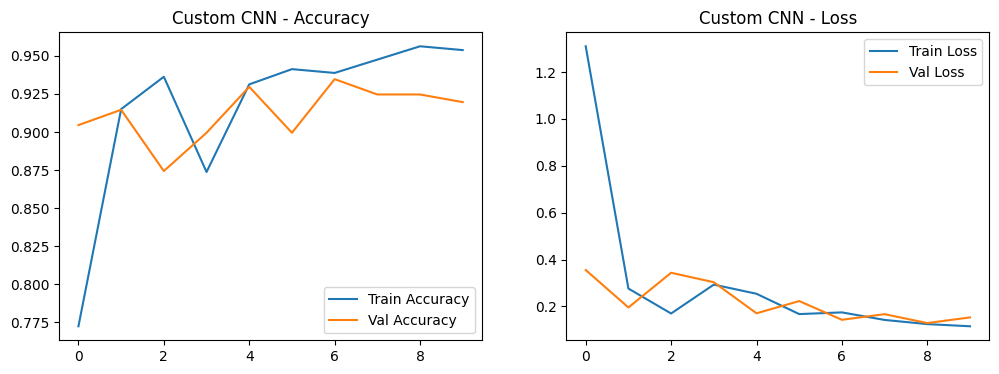

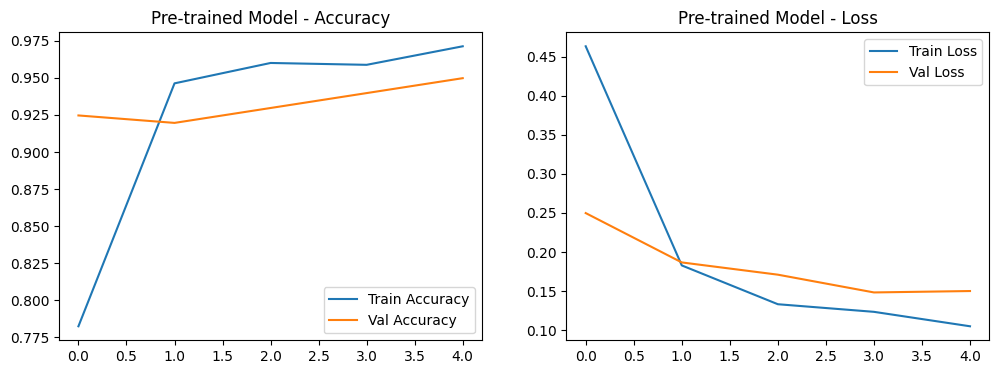

In [11]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_history(history_custom, "Custom CNN")
plot_history(history_pre, "Pre-trained Model")